# Notebook 04 — Thompson Sampling

## Motivação

O desafio central em Multi-Armed Bandits é o dilema **exploração × explotação**:
- **Explotação**: usar o braço com maior reward observado.
- **Exploração**: tentar outros braços que podem ter reward real maior.

## Algoritmo

**Thompson Sampling** mantém uma distribuição de probabilidade sobre o reward esperado de cada braço. Para recompensas Bernoulli (0/1), usamos a distribuição **Beta conjugada**:

- Prior: `Beta(α=1, β=1)` — distribuição uniforme, sem preferência inicial.
- A cada rodada:
  1. Amostrar θᵢ ~ `Beta(αᵢ, βᵢ)` para cada braço i.
  2. Selecionar o braço com maior θᵢ.
  3. Observar recompensa r ∈ {0, 1}.
  4. Atualizar: αᵢ += r, βᵢ += (1 - r).

Esta abordagem é **Bayesiana**: a incerteza é modelada explicitamente e diminui à medida que mais dados são coletados.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

from datathon_offerexp.policies import ThompsonSamplingPolicy
from datathon_offerexp.evaluation import replay_evaluate, compute_regret, summarize

sns.set_theme(style='whitegrid')
SEED = 42

In [2]:
events = pd.read_csv('../data/synthetic_enrichment/offer_events.csv')

oracle_rates = events.groupby('arm_id')['reward'].mean()
best_arm_id = int(oracle_rates.idxmax())
best_arm_rate = float(oracle_rates.max())

print('Dataset:', events.shape)
print('Melhor braço (oráculo):', best_arm_id, f'— taxa {best_arm_rate:.4f}')

Dataset: (41188, 29)
Melhor braço (oráculo): 3 — taxa 0.1186


## Visualização das distribuições Beta

Antes de executar o algoritmo, visualizamos como a distribuição Beta evolui com a observação de recompensas.

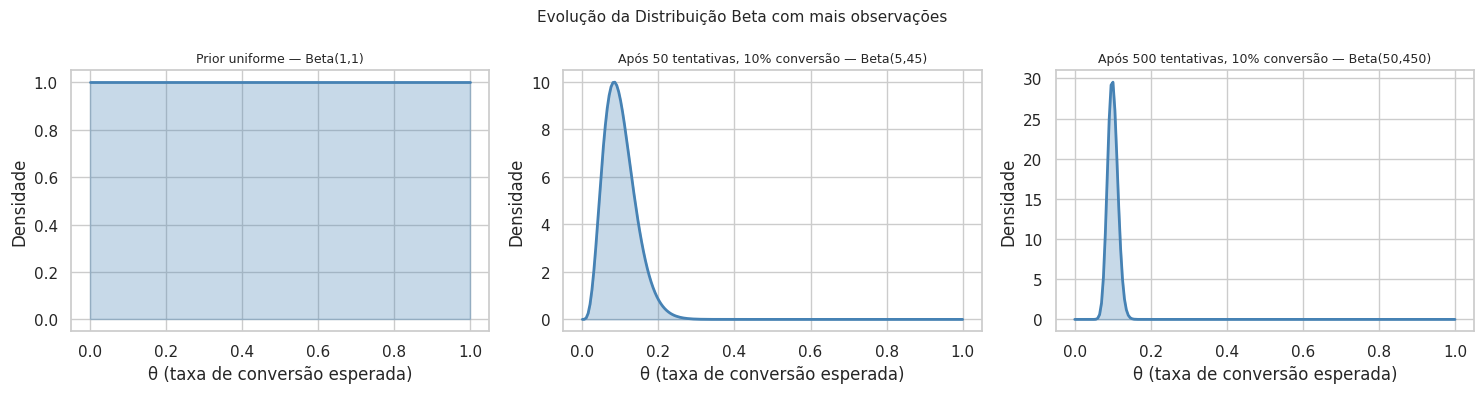

In [3]:
x = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scenarios = [
    (1, 1, 'Prior uniforme — Beta(1,1)'),
    (5, 45, 'Após 50 tentativas, 10% conversão — Beta(5,45)'),
    (50, 450, 'Após 500 tentativas, 10% conversão — Beta(50,450)'),
]
for ax, (a, b, title) in zip(axes, scenarios):
    ax.plot(x, scipy_stats.beta.pdf(x, a, b), color='steelblue', linewidth=2)
    ax.fill_between(x, scipy_stats.beta.pdf(x, a, b), alpha=0.3, color='steelblue')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('θ (taxa de conversão esperada)')
    ax.set_ylabel('Densidade')

plt.suptitle('Evolução da Distribuição Beta com mais observações', fontsize=11)
plt.tight_layout()
plt.show()

## Executando Thompson Sampling

In [4]:
ts_policy = ThompsonSamplingPolicy(seed=SEED)
df_ts = replay_evaluate(ts_policy, events, seed=SEED)
df_ts = compute_regret(df_ts, best_arm_rate)

print(summarize(df_ts, 'Thompson Sampling'))
df_ts.tail()

{'policy': 'Thompson Sampling', 'rounds': 10172, 'avg_reward': 0.111, 'total_reward': 1129.0}


,round,arm_id,arm_name,reward,cumulative_reward,avg_reward,expected_best,cumulative_regret
10167,10168,1,educacao_financeira,1.0,1126.0,0.110740,1206.389697,80.389697
10168,10169,1,educacao_financeira,1.0,1127.0,0.110827,1206.508342,79.508342
10169,10170,1,educacao_financeira,0.0,1127.0,0.110816,1206.626988,79.626988
10170,10171,1,educacao_financeira,1.0,1128.0,0.110904,1206.745634,78.745634
10171,10172,1,educacao_financeira,1.0,1129.0,0.110991,1206.864279,77.864279


## Distribuição dos braços selecionados

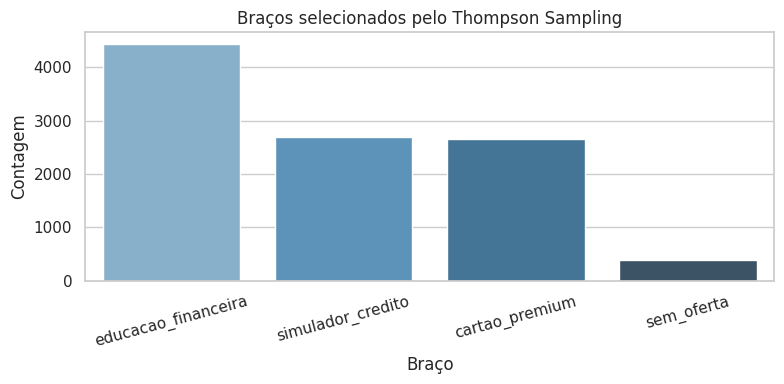

In [5]:
counts = df_ts['arm_name'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Blues_d')
ax.set_title('Braços selecionados pelo Thompson Sampling')
ax.set_xlabel('Braço')
ax.set_ylabel('Contagem')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Distribuições posteriores finais

Após processar todos os eventos, visualizamos as distribuições Beta de cada braço.

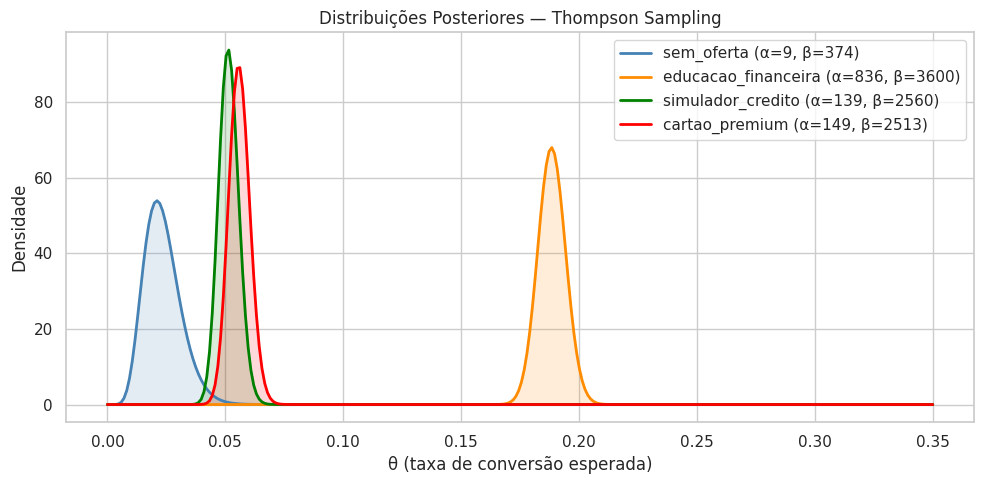

In [6]:
arm_stats = ts_policy.stats()

x = np.linspace(0, 0.35, 300)
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue', 'darkorange', 'green', 'red']
for s, color in zip(arm_stats, colors):
    pdf = scipy_stats.beta.pdf(x, s['alpha'], s['beta'])
    ax.plot(x, pdf, label=f"{s['arm_name']} (α={s['alpha']}, β={s['beta']})", color=color, linewidth=2)
    ax.fill_between(x, pdf, alpha=0.15, color=color)

ax.set_title('Distribuições Posteriores — Thompson Sampling')
ax.set_xlabel('θ (taxa de conversão esperada)')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/thompson_posteriors.png', dpi=150)
plt.show()

## Regret acumulado

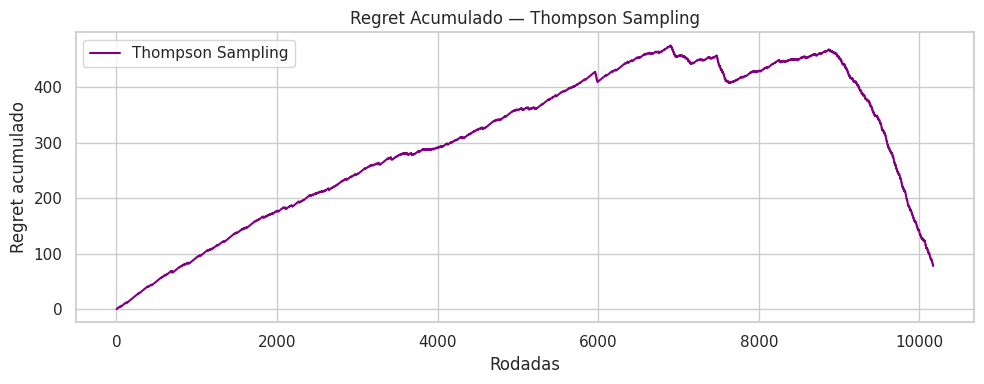

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_ts['round'], df_ts['cumulative_regret'], color='purple', label='Thompson Sampling')
ax.set_title('Regret Acumulado — Thompson Sampling')
ax.set_xlabel('Rodadas')
ax.set_ylabel('Regret acumulado')
ax.legend()
plt.tight_layout()
plt.show()

## Estatísticas finais dos braços

In [8]:
stats_df = pd.DataFrame(arm_stats)
stats_df['taxa_real_oraculo'] = oracle_rates.values
print(stats_df[['arm_name', 'trials', 'successes', 'reward_rate', 'taxa_real_oraculo', 'alpha', 'beta']].to_string(index=False))

           arm_name  trials  successes  reward_rate  taxa_real_oraculo  alpha  beta
         sem_oferta     381          8       0.0210           0.111004      9   374
educacao_financeira    4434        835       0.1883           0.111166    836  3600
  simulador_credito    2697        138       0.0512           0.109848    139  2560
     cartao_premium    2660        148       0.0556           0.118646    149  2513


## Conclusão

O Thompson Sampling:
- **Concentrou seleções** no braço com maior taxa real de conversão.
- **Explorou** os demais braços proporcionalmente à incerteza sobre seus rewards.
- **Estimativas posteriores** convergiram para as taxas reais (oráculo).
- O regret acumulado cresce de forma **sublinear** — característica desejável de algoritmos adaptativos.

No Notebook 05, comparamos formalmente Random, Greedy e Thompson Sampling.